# Chapter 3 — Defining the Internet of Things

## Hands-On Python Practice

This introductory notebook is the first complete *IoT-flavoured* Python workflow in the book. It assumes no hardware and no cloud account. The purpose is to learn a disciplined notebook workflow while connecting Python objects to the conceptual vocabulary of Chapter 3.

You will complete three exercises:

1. **A first virtual IoT device** — variables, arrays, a function, a table, and a plot.
2. **From one device to a fleet** — device identity, metadata, missing telemetry, grouping, and a fleet-level view.
3. **“Is it IoT?”** — a transparent feature matrix for distinguishing standalone embedded systems, M2M systems, cloud-only services, and IoT systems.

All data are synthetic and generated locally. The models are intentionally simple; later chapters introduce realistic sensor behaviour, networking, gateways, platforms, and deployment.

## 0. Notebook setup

Run this cell first. A good habit is to keep imports and global display settings in one place. Colab already contains NumPy, pandas, and Matplotlib, so no installation is required for this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path('.')
print('NumPy:', np.__version__)
print('pandas:', pd.__version__)
print('Matplotlib imported successfully.')

NumPy: 2.4.4
pandas: 3.0.2
Matplotlib imported successfully.


# Exercise 3.1 — Your First Virtual IoT Device

### Objective
Represent a simple connected temperature monitor as structured telemetry. The exercise introduces variables, NumPy arrays, a Python function, pandas, and Matplotlib without requiring any electronics.

### Model
A virtual room monitor samples every five minutes for one day. The synthetic temperature follows a smooth daily pattern plus small random variation. This is **not** a sensor-accuracy model; sensor characteristics are studied later in the book.

Each record contains ideas that recur throughout IoT systems: a **device identity**, a **timestamp**, a **measurement**, and simple **context metadata** such as location and unit.

In [2]:
rng = np.random.default_rng(42)

device_id = 'room-01'
sample_period_min = 5
n_samples = 24 * 60 // sample_period_min

minutes = np.arange(n_samples) * sample_period_min
hours = minutes / 60.0
timestamps = pd.date_range('2026-01-15 00:00:00', periods=n_samples, freq=f'{sample_period_min}min')

def virtual_temperature(hour, noise):
    # A transparent synthetic daily profile; not a physical sensor model.
    return 21.5 + 2.2 * np.sin(2 * np.pi * (hour - 7) / 24) + noise

noise = rng.normal(0.0, 0.25, size=n_samples)
temperature_c = virtual_temperature(hours, noise)

telemetry = pd.DataFrame({
    'device_id': device_id,
    'timestamp': timestamps,
    'temperature_c': temperature_c.round(2),
    'zone': 'office',
    'unit': 'degC',
})
telemetry.head()

,device_id,timestamp,temperature_c,zone,unit
0,room-01,2026-01-15 00:00:00,19.45,office,degC
1,room-01,2026-01-15 00:05:00,19.10,office,degC
2,room-01,2026-01-15 00:10:00,19.54,office,degC
3,room-01,2026-01-15 00:15:00,19.58,office,degC
4,room-01,2026-01-15 00:20:00,18.85,office,degC


In [3]:
summary_31 = {
    'records': len(telemetry),
    'mean_c': telemetry['temperature_c'].mean(),
    'min_c': telemetry['temperature_c'].min(),
    'max_c': telemetry['temperature_c'].max(),
}
summary_31

{'records': 288,
 'mean_c': np.float64(21.49170138888889),
 'min_c': np.float64(18.85),
 'max_c': np.float64(24.28)}

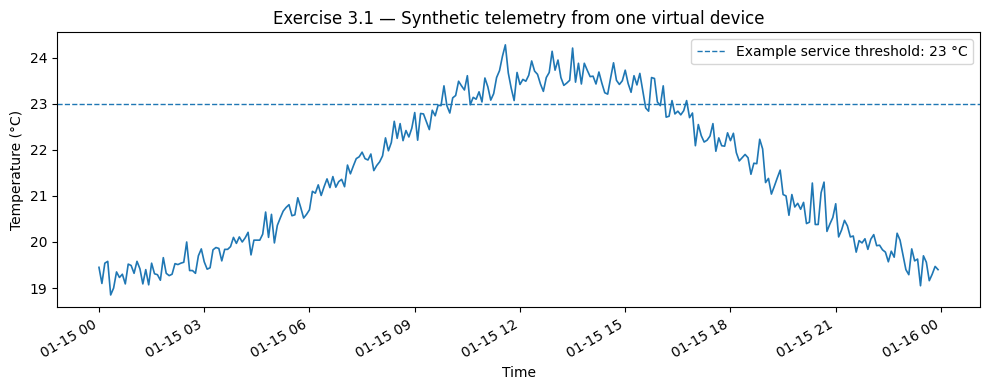

Records above 23 °C: 72 of 288


In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(telemetry['timestamp'], telemetry['temperature_c'], linewidth=1.2)
ax.axhline(23.0, linestyle='--', linewidth=1.0, label='Example service threshold: 23 °C')
ax.set_title('Exercise 3.1 — Synthetic telemetry from one virtual device')
ax.set_xlabel('Time')
ax.set_ylabel('Temperature (°C)')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_3_1_virtual_device.png', dpi=180, bbox_inches='tight')
plt.show()

alert_records = telemetry[telemetry['temperature_c'] > 23.0]
print(f'Records above 23 °C: {len(alert_records)} of {len(telemetry)}')

### Interpretation

The important result is not the exact temperature curve. It is the data structure: the same device produces a sequence of timestamped observations with identity and context that can be stored, transmitted, aggregated, and interpreted by another component. The simple threshold is an example of a *service rule* built on top of telemetry.

The **sampling interval** and the **network reporting interval** do not have to be identical. A battery-powered device might sample locally every five minutes but transmit several samples together less often. The appropriate trade-off depends on latency, energy, storage, and communication requirements and is studied quantitatively in later chapters.

### Challenge tasks
- Compare 5-, 15-, and 60-minute sampling intervals. How many records does each produce in one day?
- Add a second measurement such as synthetic humidity.
- Change the service threshold and count how many records trigger it.
- Export the table with `telemetry.to_csv('telemetry.csv', index=False)` and inspect the file.
- Propose a different network reporting interval from the sampling interval and explain why the two might differ.

# Exercise 3.2 — From One Device to an IoT Fleet

### Objective
Scale the previous idea from one device to a small fleet and show why identity and metadata matter.

### Model
Twelve virtual devices report every 15 minutes for one day, so each device has **96 scheduled reports** (`N_expected = 96`). Each device belongs to one of three zones. Most scheduled reports have a 4% probability of being absent; one deliberately degraded node has an 18% probability. Missing records represent *unavailable telemetry*, not a detailed radio-channel model. Networking mechanisms are studied later.

The exercise uses loops, dictionaries, metadata, and `groupby` to move from per-device generation to a fleet-level completeness view. Because the data are random but generated with a fixed seed, the realised completeness is reproducible while still illustrating the difference between an expected value and one finite observation window.


In [5]:
rng = np.random.default_rng(314)

N_DEVICES = 12
SAMPLES_PER_DEVICE = 24 * 4
base_time = pd.Timestamp('2026-01-16 00:00:00')
times = pd.date_range(base_time, periods=SAMPLES_PER_DEVICE, freq='15min')
zones = ['Lab', 'Office', 'Hall']
zone_base = {'Lab': 22.2, 'Office': 21.5, 'Hall': 20.7}

rows = []
for i in range(N_DEVICES):
    device = f'node-{i+1:02d}'
    zone = zones[i % len(zones)]
    drop_probability = 0.18 if device == 'node-07' else 0.04
    device_offset = rng.normal(0.0, 0.18)

    for k, ts in enumerate(times):
        if rng.random() < drop_probability:
            continue
        hour = ts.hour + ts.minute / 60.0
        value = (
            zone_base[zone]
            + 1.5 * np.sin(2 * np.pi * (hour - 7) / 24)
            + device_offset
            + rng.normal(0.0, 0.20)
        )
        rows.append({
            'device_id': device,
            'zone': zone,
            'timestamp': ts,
            'temperature_c': round(value, 2),
        })

fleet = pd.DataFrame(rows)
fleet.head()

,device_id,zone,timestamp,temperature_c
0,node-01,Lab,2026-01-16 00:00:00,20.65
1,node-01,Lab,2026-01-16 00:15:00,20.62
2,node-01,Lab,2026-01-16 00:30:00,20.63
3,node-01,Lab,2026-01-16 00:45:00,20.56
4,node-01,Lab,2026-01-16 01:00:00,20.22


In [6]:
N_EXPECTED = SAMPLES_PER_DEVICE
per_device = (
    fleet.groupby(['device_id', 'zone'])
         .agg(received=('temperature_c', 'size'),
              mean_temperature_c=('temperature_c', 'mean'),
              max_temperature_c=('temperature_c', 'max'))
         .reset_index()
)
per_device['completeness_pct'] = 100 * per_device['received'] / N_EXPECTED
per_device['mean_temperature_c'] = per_device['mean_temperature_c'].round(2)
per_device['max_temperature_c'] = per_device['max_temperature_c'].round(2)
per_device

,device_id,zone,received,mean_temperature_c,max_temperature_c,completeness_pct
0,node-01,Lab,90,22.08,23.84,93.750000
1,node-02,Office,94,21.47,23.32,97.916667
2,node-03,Hall,92,20.36,22.39,95.833333
3,node-04,Lab,90,22.14,23.82,93.750000
4,node-05,Office,90,21.35,23.07,93.750000
5,node-06,Hall,95,20.46,22.45,98.958333
6,node-07,Lab,79,22.19,24.08,82.291667
7,node-08,Office,92,21.34,23.14,95.833333
8,node-09,Hall,92,20.53,22.32,95.833333
9,node-10,Lab,91,22.41,24.13,94.791667


In [7]:
expected_fleet_completeness = 100 * (11 * 0.96 + 0.82) / 12
fleet_completeness = 100 * len(fleet) / (N_DEVICES * N_EXPECTED)
worst = per_device.sort_values('completeness_pct').iloc[0]
print(f'Model-expected fleet completeness: {expected_fleet_completeness:.1f}%')
print(f'Fixed-seed one-day realisation: {fleet_completeness:.1f}%')
print(f'Lowest-completeness device: {worst.device_id} ({worst.completeness_pct:.1f}%)')

Model-expected fleet completeness: 94.8%
Fixed-seed one-day realisation: 94.4%
Lowest-completeness device: node-07 (82.3%)


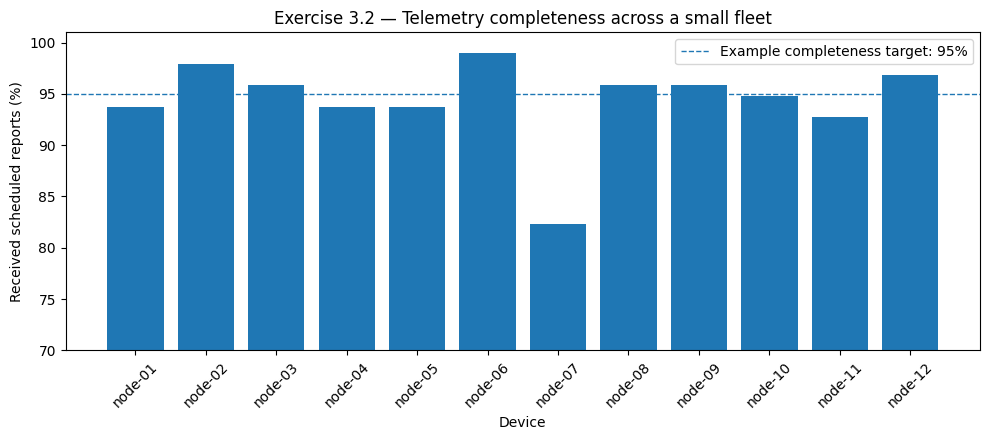

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(per_device['device_id'], per_device['completeness_pct'])
ax.axhline(95, linestyle='--', linewidth=1.0, label='Example completeness target: 95%')
ax.set_ylim(70, 101)
ax.set_ylabel('Received scheduled reports (%)')
ax.set_xlabel('Device')
ax.set_title('Exercise 3.2 — Telemetry completeness across a small fleet')
ax.tick_params(axis='x', rotation=45)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_3_2_fleet.png', dpi=180, bbox_inches='tight')
plt.show()

### Interpretation

A fleet-level service must know *which* device produced each record and which reports were expected. The degraded device is visible only after measurements are combined with identity and schedule metadata. This is one reason IoT systems need more than raw sensor values.

### Challenge tasks
- Calculate completeness by zone.
- Mark devices below 95% completeness and print their IDs.
- Add a `firmware_version` field and group devices by version.
- Instead of deleting unavailable reports, keep every scheduled timestamp and represent missing measurements with `NaN`. Discuss when that representation is preferable.

# Exercise 3.3 — “Is It IoT?” A Boundary-Aware IoT Classification Matrix

### Objective
Use explicit features and system boundaries to reason about cases that are often labelled inconsistently.

There is no universal numeric “IoT score”. The matrix below is a **teaching instrument**, not a standard and not a universal classifier. It separates observable properties from a **scope-aware classification**. This matters because the same PLC, gateway, cloud service, or sensor can be a component of an IoT deployment without constituting a complete IoT system by itself.

### Descriptive features
The matrix records six useful properties:

1. interaction with the physical world through a sensor or actuator;
2. network exchange;
3. an identifiable endpoint identity;
4. automated data and/or control exchange;
5. participation in an application, service, or management function beyond the endpoint itself; and
6. whether **physical** actuation is present (regardless of whether it is triggered locally or by a remote command).

The sixth property is deliberately **descriptive rather than mandatory**. A monitoring-only IoT product can qualify without actuation. Likewise, a feature vector alone may not resolve every boundary case: the scope and relationship among components still matter.


In [9]:
features = [
    'Physical transducer',
    'Network exchange',
    'Endpoint identity',
    'Automated data/control',
    'Application/service participation',
    'Actuation present',
]

scenarios = {
    'Standalone non-networked thermometer': [1, 0, 1, 1, 0, 0],
    'Dedicated PLC–supervisor link':         [1, 1, 1, 1, 1, 0],
    'Networked tank-level monitor':          [1, 1, 1, 1, 1, 0],
    'Networked irrigation controller':       [1, 1, 1, 1, 1, 1],
    'Standalone cloud analytics service':    [0, 1, 0, 1, 1, 0],
    'Wearable via smartphone gateway':       [1, 1, 1, 1, 1, 0],
}

feature_matrix = pd.DataFrame.from_dict(scenarios, orient='index', columns=features)
feature_matrix


,Physical transducer,Network exchange,Endpoint identity,Automated data/control,Application/service participation,Actuation present
Standalone non-networked thermometer,1,0,1,1,0,0
Dedicated PLC–supervisor link,1,1,1,1,1,0
Networked tank-level monitor,1,1,1,1,1,0
Networked irrigation controller,1,1,1,1,1,1
Standalone cloud analytics service,0,1,0,1,1,0
Wearable via smartphone gateway,1,1,1,1,1,0


In [10]:
classifications = {
    'Standalone non-networked thermometer': 'Standalone embedded system',
    'Dedicated PLC–supervisor link': 'M2M; also satisfies the IoT working definition',
    'Networked tank-level monitor': 'IoT system/deployment',
    'Networked irrigation controller': 'IoT system/deployment',
    'Standalone cloud analytics service': 'IoT application/component',
    'Wearable via smartphone gateway': 'IoT system/deployment',
}

feature_matrix['Scope-aware classification'] = pd.Series(classifications)
feature_matrix[['Scope-aware classification']]


,Scope-aware classification
Standalone non-networked thermometer,Standalone embedded system
Dedicated PLC–supervisor link,M2M; also satisfies the IoT working definition
Networked tank-level monitor,IoT system/deployment
Networked irrigation controller,IoT system/deployment
Standalone cloud analytics service,IoT application/component
Wearable via smartphone gateway,IoT system/deployment


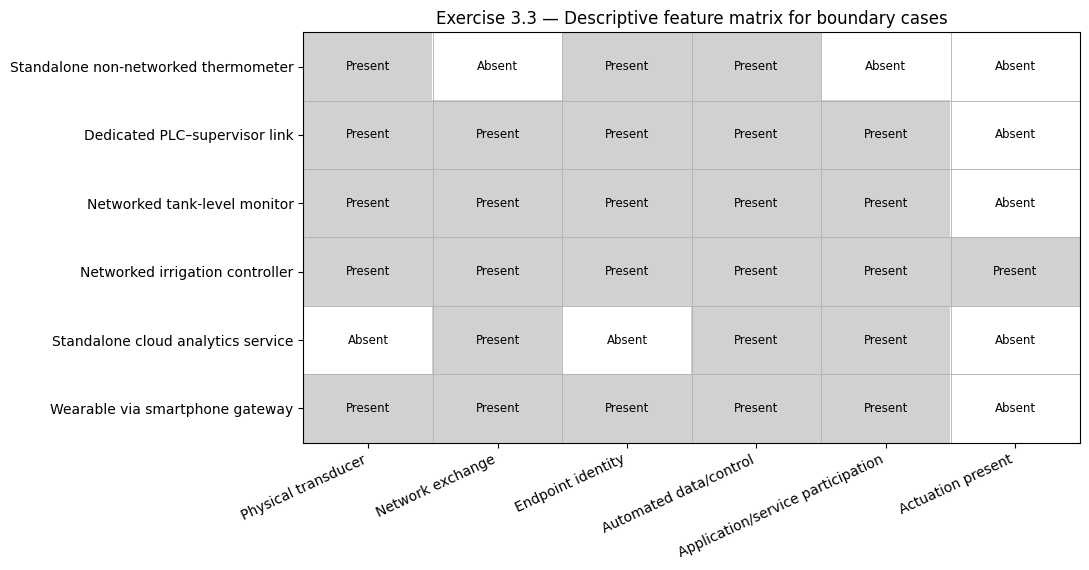

In [11]:
from matplotlib.colors import ListedColormap

plot_matrix = feature_matrix[features].to_numpy()
fig, ax = plt.subplots(figsize=(11, 5.8))
ax.imshow(plot_matrix, aspect='auto', cmap=ListedColormap(['white', '0.82']), vmin=0, vmax=1)
ax.set_xticks(np.arange(len(features)), labels=features)
ax.set_yticks(np.arange(len(feature_matrix.index)), labels=feature_matrix.index)
ax.set_title('Exercise 3.3 — Descriptive feature matrix for boundary cases')

for r in range(plot_matrix.shape[0]):
    for c in range(plot_matrix.shape[1]):
        ax.text(c, r, 'Present' if plot_matrix[r, c] else 'Absent', ha='center', va='center', fontsize=8.5)

# Gridlines emphasise that the matrix is categorical, not a continuous score.
ax.set_xticks(np.arange(-0.5, len(features), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(feature_matrix.index), 1), minor=True)
ax.grid(which='minor', linewidth=0.6)
ax.tick_params(which='minor', bottom=False, left=False)
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_3_3_iot_scorecard.png', dpi=180, bbox_inches='tight')
plt.show()

### Interpretation

The **standalone non-networked thermometer** is an embedded sensing system, not an IoT system, because its measurement never participates in a networked application or service. It may still carry a serial number or another on-device identifier, so endpoint identity is recorded as present; identity alone does not change the classification. A Bluetooth- or Zigbee-enabled thermometer could be different; the boundary depends on the actual system, not the product name.

The **dedicated PLC–supervisor link** is the most instructive case because two labels are both correct at once. It is a legitimate example of traditional M2M communication, and it also satisfies the minimum properties of the chapter's working IoT definition: an identifiable endpoint, automated data exchange, and a supervisory application beyond the endpoint. If that same plant-level link is later integrated through a gateway or service into plant analytics, MES, ERP, or another broader application, describing the wider deployment as IIoT becomes more informative — but that broader integration is what makes the IIoT framing useful, not what makes the relationship IoT for the first time. Actuation is recorded as absent only because the stated boundary covers the supervisory telemetry relationship, not because PLCs lack actuators in general.

The **standalone cloud analytics service** can be an important component of an IoT product or deployment, but it is not an IoT device and is not a complete IoT system by itself because the selected system boundary contains no physical endpoint.

The **tank-level monitor**, **irrigation controller**, and **wearable** scenarios share a pattern worth making explicit rather than collapsing into one label. In each case the physical unit itself is the IoT *device*. Combined with its back-end service, control application, or companion app, the scenario as modelled is an IoT *system/deployment*. If a manufacturer sells the device together with its companion application or back-end service as a single offering, that bundle is what NIST IR 8259 Rev. 1 calls an IoT *product*. The monitor and the irrigation controller differ only in one feature: the monitor is deliberately monitoring-only, while the controller also actuates — neither requires actuation to qualify.

Classification depends on both the stated criteria and the system boundary. Components should not be confused with complete systems.

### Challenge tasks
- Extend the PLC scenario with an edge gateway and a plant-level analytics service. Explain how the system boundary changes which framing (M2M, IoT, IIoT) is most informative.
- Add a networked light bulb controlled only by a local home-automation application. Does public Internet access matter?
- Add a conventional web server. Why is network connectivity alone insufficient?
- Choose one scenario and classify separately the physical device, the application/service component, and the complete product/system.


# Practice summary

You have now used the same Python workflow that later chapters will deepen:

- define the problem and assumptions;
- represent device identity, telemetry, and context explicitly;
- transform raw records into a small engineering metric;
- distinguish an expected stochastic result from one reproducible finite realisation;
- visualise the result;
- distinguish devices, product components, and complete systems when discussing IoT boundaries; and
- document the rule used for interpretation.

In later chapters, the synthetic “device” becomes a real embedded endpoint, the missing records become a networking problem, the service layer becomes a gateway/platform problem, and the simple measurements become calibrated sensor and data-acquisition pipelines.

## Reproducibility checks

These checks are intentionally simple. They detect accidental changes to the deterministic examples used in the chapter text.

In [12]:
assert len(telemetry) == 288
assert N_DEVICES == 12 and SAMPLES_PER_DEVICE == 96 and N_EXPECTED == 96
assert feature_matrix.loc['Standalone non-networked thermometer', 'Scope-aware classification'] == 'Standalone embedded system'
assert feature_matrix.loc['Dedicated PLC–supervisor link', 'Scope-aware classification'] == 'M2M; also satisfies the IoT working definition'
assert feature_matrix.loc['Networked irrigation controller', 'Scope-aware classification'] == 'IoT system/deployment'
assert feature_matrix.loc['Standalone cloud analytics service', 'Scope-aware classification'] == 'IoT application/component'
print('Reproducibility checks: OK')


Reproducibility checks: OK
